# TGV² tomography — Forward–Backward with deviations

Same problem as the denoising code (`NN_claude`), adapted to **tomography** (Radon transform, ODL + ASTRA).
This notebook checks that **everything works**:

1. the phantom, the sinogram, the back-projection;
2. the numerical conditions `||A|| = 1` and the explicit-step bound `γ < 2/(λ₀β̄)`;
3. **`run_zero` (zero deviations) converges to the correct solution** — this is the acceptance test;
4. the KKT residual vs the `O(1/t)` / `O(1/t²)` reference rates;
5. the distance to the optimal image `‖u_t − u*‖₂/‖u*‖₂`, using a far-run **PDHG** as the reference `u*`;
6. the reconstruction vs the phantom (PSNR);
7. an independent **PDHG** baseline solving the *same* objective, compared to `run_zero` (PSNR + images).

## 0. Imports & configuration

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from Algo_setuptorch import Params, get_setup, build_algo_functions
from run import run_zero, run_random
from pdhg_tomography_tgv import run_pdhg
from PSNR import psnr_history

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device =', device)

# For a quick CPU/skimage test, lower SIZE (e.g. 64) and T_BASELINE.
SIZE       = 128
N_ANGLES   = 180
T=100
T_BASELINE = T
NOISE = 0.05      # test problem: 2% noise on the sinogram
PDHG_ITERS = T

T_CMP = T

params = Params(size=SIZE)
SHAPES = [
    (1, 1, SIZE, SIZE),   # u  (image)
    (1, 2, SIZE, SIZE),   # w
    (1, 2, SIZE, SIZE),   # p
    (1, 3, SIZE, SIZE),   # q
]
N_CH_primal = sum(s[1] for s in SHAPES[:2])   # = 3

device = cuda


## 1. The problem: phantom, sinogram, back-projection

`get_setup` builds the Radon transform (normalized to `||A|| = 1`), the `tgv_phantom`,
the sinogram `y = A·phantom`, and the back-projection `Aᵀy` used as initialization.

||A|| (normalized) = 1.000
||B|| (TGV)        = 3.206


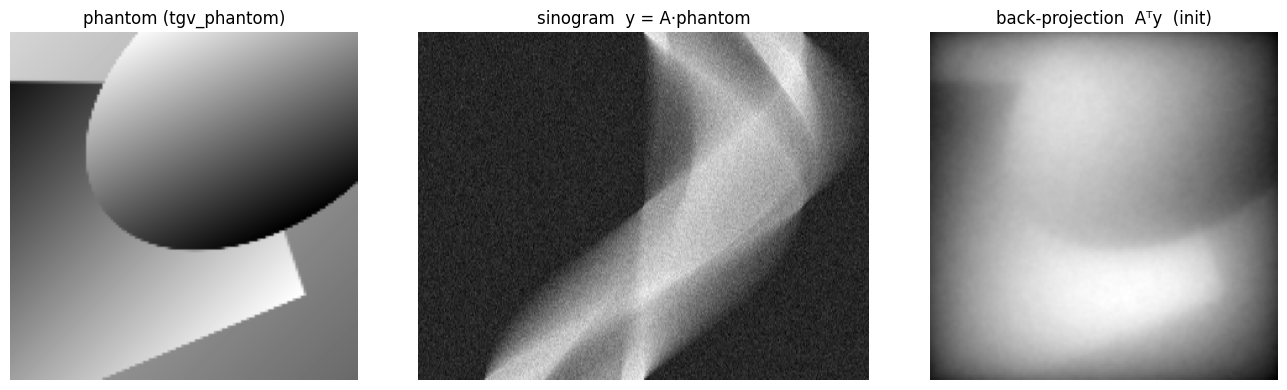

In [2]:
# One shared problem used by BOTH solvers (run_zero and PDHG) -> identical objective.
setup = get_setup(SIZE, n_angles=N_ANGLES, seed=1000, noise_level=NOISE, device=device)

phantom = setup['phantom']        # [1,1,H,W] ground truth
sino    = setup['data']           # [1,1,n_angles,n_det] sinogram
init    = setup['initial_state']  # [1,1,H,W] back-projection (algorithm start)

print(f"||A|| (normalized) = {setup['norm_A']:.3f}")
print(f"||B|| (TGV)        = {setup['norm_B']:.3f}")

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
ax[0].imshow(phantom[0,0].cpu(), cmap='gray'); ax[0].set_title('phantom (tgv_phantom)'); ax[0].axis('off')
ax[1].imshow(sino[0,0].cpu(), cmap='gray', aspect='auto'); ax[1].set_title('sinogram  y = A·phantom'); ax[1].axis('off')
ax[2].imshow(init[0,0].cpu(), cmap='gray'); ax[2].set_title('back-projection  Aᵀy  (init)'); ax[2].axis('off')
plt.tight_layout(); plt.show()

## 2. Numerical conditions

The inner resolvent `(I+γA)⁻¹` is now solved by **FISTA**, which converges for *any* `γ`. So `γ` is **no longer** tied to `‖B‖` — the old contractive-resolvent condition `γ‖B‖ < 1` is gone. The only remaining constraint is the one given by the paper for the explicit forward step (cocoercivity of the data term, i.e. `θ̂ₙ > 0`):

$$\gamma < \frac{2}{\lambda_0\,\bar\beta},\qquad \bar\beta = \|A\|^2 = 1.$$

`build_algo_functions` sets `β̄ = ||A||² = 1` and `γ = 0.85·2/(λ₀β̄)` automatically. `‖B‖` is still estimated, but only feeds the FISTA Lipschitz constant `L = 1 + (γ‖B‖)²` inside the resolvent.

In [3]:
functions = build_algo_functions(setup, params)
gamma_max = 2.0 / (params.lam0 * params.beta_bar)   # paper condition: gamma < 2/(lam0*beta_bar)
print(f'gamma             = {params.gamma0:.4f}')
print(f'beta_bar          = {params.beta_bar:.3f}')
print(f'2/(lam0*beta_bar) = {gamma_max:.4f}   (paper bound: gamma must be < this)')
print(f'condition gamma < 2/(lam0*beta_bar): {bool(params.gamma0 < gamma_max)}')
print(f'||B|| = {setup["norm_B"]:.3f}   (only feeds the FISTA resolvent Lipschitz constant; no longer constrains gamma)')
print(f'alpha1 = alpha2 = {params.alpha1}')

gamma             = 1.8889
beta_bar          = 1.000
2/(lam0*beta_bar) = 2.2222   (paper bound: gamma must be < this)
condition gamma < 2/(lam0*beta_bar): True
||B|| = 3.206   (only feeds the FISTA resolvent Lipschitz constant; no longer constrains gamma)
alpha1 = alpha2 = 0.1


## 3. `run_zero` (acceptance test)

Run the algorithm with **zero deviations** on the shared problem.
The KKT residual must drop by several orders of magnitude: the inclusion is solved.

In [4]:
init_t  = setup['initial_state']
clean_t = setup['phantom']

AxCx_zero, res_zero, x_hist = run_zero(init_t, functions, params, SHAPES, T=T_BASELINE, device=device)
AxCx_rand, res_rand, x_hist_rand=run_random(init_t, functions, params, SHAPES, T=T_BASELINE, device=device)


rec0  = x_hist[-1][0]
psnr0 = psnr_history([rec0], clean_t)[0]
rec_rand = x_hist_rand[-1][0]
psnr_rand = psnr_history([rec_rand], clean_t)[0]
print(f'KKT : {AxCx_zero[0]:.3e} -> {AxCx_zero[-1]:.3e}   (factor {AxCx_zero[0]/max(AxCx_zero[-1],1e-30):.1e})')
print(f'run_zero reconstruction PSNR = {psnr0:.2f} dB')

iter:0
45.834495544433594
iter:1


31.781789779663086
iter:2
22.06509017944336
iter:3
15.334609985351562
iter:4
10.661828994750977
iter:5
7.4175333976745605
iter:6
5.164577960968018
iter:7
3.600839853286743
iter:8
2.516810894012451
iter:9
1.7667560577392578
iter:10
1.250934362411499
iter:11
0.8973216414451599
iter:12
0.6590311527252197
iter:13
0.49918773770332336
iter:14
0.39533504843711853
iter:15
0.32932642102241516
iter:16
0.2883063554763794
iter:17
0.2622012794017792
iter:18
0.24528756737709045
iter:19
0.23232270777225494
iter:20
0.2194126695394516
iter:21
0.21272507309913635
iter:22
0.20700548589229584
iter:23
0.19548675417900085
iter:24
0.18805907666683197
iter:25
0.17986710369586945
iter:26
0.17209351062774658
iter:27
0.1662629097700119
iter:28
0.16082504391670227
iter:29
0.1538836807012558
iter:30
0.1489040106534958
iter:31
0.1440359652042389
iter:32
0.1392730474472046
iter:33
0.13494925200939178
iter:34
0.13056154549121857
iter:35
0.12693379819393158
iter:36
0.1221972331404686
iter:37
0.12090764939785004
iter:3

## 4. Convergence with the `O(1/t)` / `O(1/t²)` reference rates

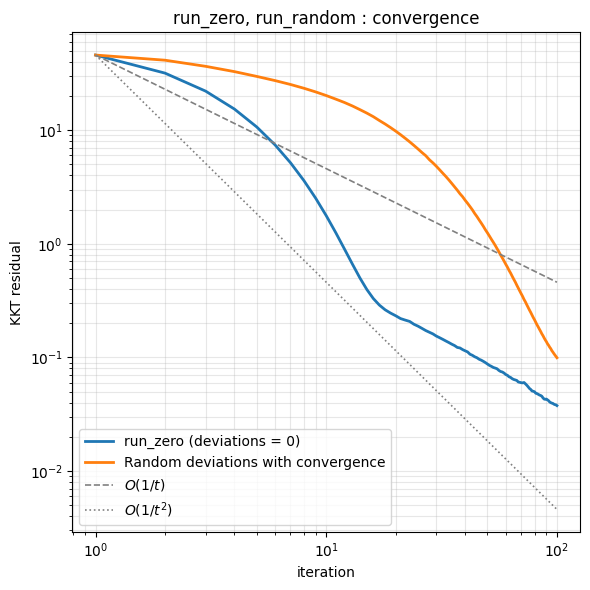

In [5]:
t = np.arange(1, len(AxCx_zero)+1)
c = AxCx_zero[0]
plt.figure(figsize=(6,6))
plt.loglog(t, AxCx_zero, lw=2, label='run_zero (deviations = 0)')
plt.loglog(t, AxCx_rand, lw=2, label='Random deviations with convergence')
plt.loglog(t, c/t,    'gray', ls='--', lw=1.2, label=r'$O(1/t)$')
plt.loglog(t, c/t**2, 'gray', ls=':',  lw=1.2, label=r'$O(1/t^2)$')
plt.xlabel('iteration'); plt.ylabel('KKT residual'); plt.title('run_zero, run_random : convergence')
plt.legend(); plt.grid(True, which='both', alpha=0.3); plt.tight_layout(); plt.show()

## 4 bis. Distance to the optimal image `u*` (L2 to a PDHG reference)

The KKT residual shows the inclusion is solved; here we measure **directly** how fast `run_zero` reaches the **optimal image**. We approximate `u*` by running PDHG (an independent solver of the *same* objective) for many iterations, **cache it on disk** (keyed by a hash of the problem instance, so it is computed only once), and report the relative L2 distance `‖u_t − u*‖₂ / ‖u*‖₂` at every iteration. `run_zero` with **zero deviations must drive this distance toward 0** — this is the convergence-to-the-solution test.

In [7]:
from reference import load_reference, l2_distance_history

# Load the precomputed reference image u* (run `python reference.py` once to create it).
u_ref = load_reference("u_ref_0_2.pt",device=device)

# Relative L2 distance of the run_zero iterates to the reference.
l2_zero = l2_distance_history(x_hist, u_ref)
l2_rand=l2_distance_history(x_hist_rand, u_ref)
print(f'run_zero L2-to-ref : {l2_zero[0]:.3e} -> {l2_zero[-1]:.3e}  '
      f'(factor {l2_zero[0]/max(l2_zero[-1],1e-30):.1e})')

run_zero L2-to-ref : 6.842e-01 -> 1.077e-02  (factor 6.4e+01)


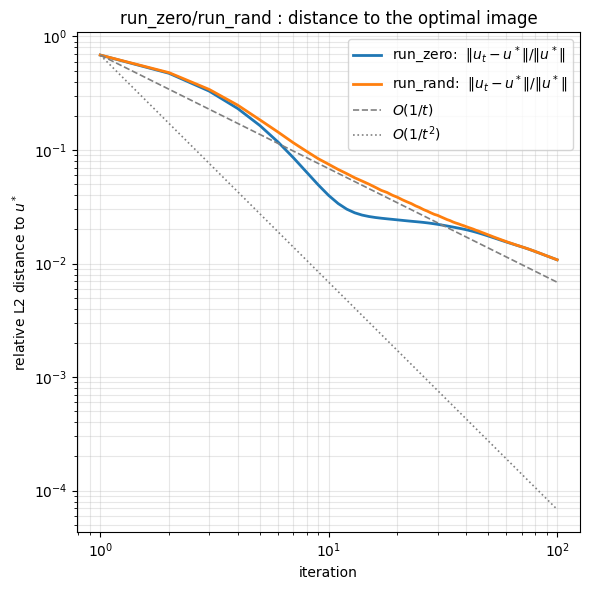

In [8]:
t = np.arange(1, len(l2_zero)+1)
c = l2_zero[0]
plt.figure(figsize=(6,6))
plt.loglog(t, l2_zero, lw=2, label=r'run_zero:  $\|u_t-u^*\|/\|u^*\|$')
plt.loglog(t, l2_rand, lw=2, label=r'run_rand:  $\|u_t-u^*\|/\|u^*\|$')
plt.loglog(t, c/t,    'gray', ls='--', lw=1.2, label=r'$O(1/t)$')
plt.loglog(t, c/t**2, 'gray', ls=':',  lw=1.2, label=r'$O(1/t^2)$')
plt.xlabel('iteration'); plt.ylabel(r'relative L2 distance to $u^*$')
plt.title('run_zero/run_rand : distance to the optimal image')
plt.legend(); plt.grid(True, which='both', alpha=0.3); plt.tight_layout(); plt.show()

## 5. Reconstruction at the final iteration

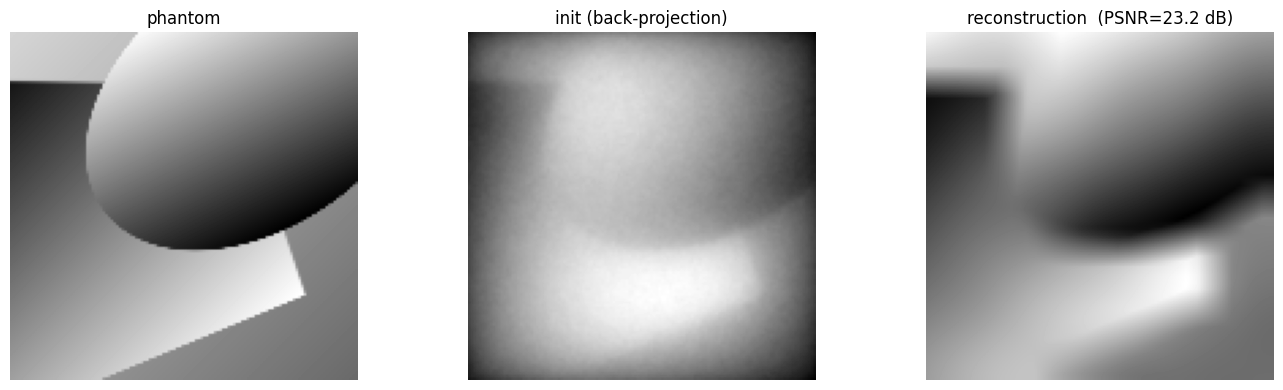

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
ax[0].imshow(clean_t[0,0].cpu(), cmap='gray'); ax[0].set_title('phantom'); ax[0].axis('off')
ax[1].imshow(init_t[0,0].cpu(), cmap='gray'); ax[1].set_title('init (back-projection)'); ax[1].axis('off')
ax[2].imshow(rec0[0,0].cpu(), cmap='gray'); ax[2].set_title(f'reconstruction  (PSNR={psnr0:.1f} dB)'); ax[2].axis('off')
plt.tight_layout(); plt.show()

## 6. PDHG baseline — same problem, independent solver

`run_pdhg` solves the **exact same** objective `½‖Au−y‖² + α₁‖∇u−w‖₁ + α₂‖Ew‖₁`
on the **same** `setup` (same normalised `A`, same sinogram `y`, same anisotropic TGV weights).
Since both solvers target the same minimiser, their reconstructions should match — this is an
independent cross-check of the inclusion formulation.

In [10]:
rec_pdhg  = run_pdhg(setup, params, niter=PDHG_ITERS, verbose=False)
psnr_pdhg = psnr_history([rec_pdhg], clean_t)[0]

diff = (rec0[0,0] - rec_pdhg[0,0]).abs()
rel  = diff.norm() / rec_pdhg[0,0].norm().clamp(min=1e-12)
print(f'run_zero PSNR = {psnr0:.2f} dB')
print(f'PDHG     PSNR = {psnr_pdhg:.2f} dB')
print(f'relative L2 difference between the two reconstructions = {rel.item():.3e}')

run_zero PSNR = 23.21 dB
PDHG     PSNR = 23.24 dB
relative L2 difference between the two reconstructions = 2.857e-02


### Visual comparison

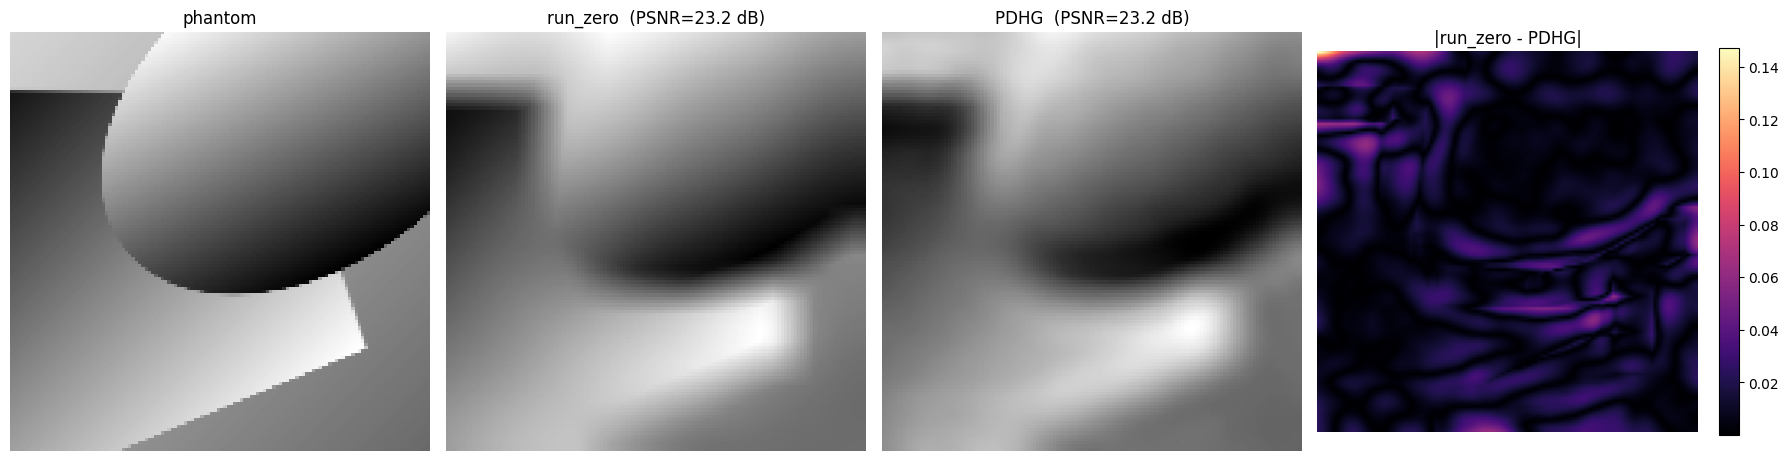

In [11]:
fig, ax = plt.subplots(1, 4, figsize=(18, 4.5))
ax[0].imshow(clean_t[0,0].cpu(), cmap='gray'); ax[0].set_title('phantom'); ax[0].axis('off')
ax[1].imshow(rec0[0,0].cpu(), cmap='gray'); ax[1].set_title(f'run_zero  (PSNR={psnr0:.1f} dB)'); ax[1].axis('off')
ax[2].imshow(rec_pdhg[0,0].cpu(), cmap='gray'); ax[2].set_title(f'PDHG  (PSNR={psnr_pdhg:.1f} dB)'); ax[2].axis('off')
im = ax[3].imshow((rec0[0,0]-rec_pdhg[0,0]).abs().cpu(), cmap='magma'); ax[3].set_title('|run_zero - PDHG|'); ax[3].axis('off')
fig.colorbar(im, ax=ax[3], fraction=0.046)
plt.tight_layout(); plt.show()

## 7. Learned deviations — zero vs learned vs PDHG

We load the trained `UnrolledFBS` checkpoint and run it with **learned, safeguarded deviations** for `T_CMP` iterations, then compare against the `run_zero` baseline (KKT residual, log-log) and the PDHG baseline (reconstruction quality, PSNR). All solvers share the same `setup`.

In [19]:
from algorithm.unrolled_model import UnrolledFBS
from run import run_learned


CKPT  = 'checkpoint_tomo_128_gamma_1.8.pt'

# Rebuild the model with the SAME architecture used at training time (main.py).
model = UnrolledFBS(params=params, shapes=SHAPES, n_channels=N_CH_primal,
                    T=10, alpha=0.99).to(device).float()
ckpt  = torch.load(CKPT, map_location=device)
state = ckpt['model'] if isinstance(ckpt, dict) and 'model' in ckpt else ckpt
model.load_state_dict(state)
model.eval()
print(f'loaded {CKPT}  |  params = {sum(p.numel() for p in model.parameters()):,}')


loaded checkpoint_tomo_128_gamma_1.8.pt  |  params = 596,230


In [20]:
# Zero-deviation baseline (reuse the first T_CMP iterates already computed).
res_zero_cmp  = np.asarray(AxCx_zero[:T_CMP])
res_rand_cmp  = np.asarray(AxCx_rand[:T_CMP])

# Learned deviations.
AxCx_learned, _res_l, hist_l = run_learned(
    model, init_t, clean_t, functions, T_test=T_CMP, return_all=True)
res_learned_cmp = np.asarray(AxCx_learned[:T_CMP])

# PDHG over the same horizon, tracking PSNR at every iteration via the hook.
def _psnr_track(u, w):
    return psnr_history([u], clean_t)[0]
rec_pdhg_cmp, psnr_pdhg = run_pdhg(setup, params, niter=T_CMP,
                                   verbose=False, obj_fn=_psnr_track)

# PSNR trajectories for the inclusion solvers.
psnr_zero    = psnr_history(x_hist[:T_CMP], clean_t)
psnr_learned = psnr_history(hist_l['x'][:T_CMP], clean_t)

print(f'PSNR @ {T_CMP} iters  |  zero {psnr_zero[-1]:.2f}  '
      f'learned {psnr_learned[-1]:.2f}  PDHG {psnr_pdhg[-1]:.2f} dB')


iter:0
36.61988830566406
iter:1
10.087507247924805
iter:2
8.103204727172852
iter:3
8.89190673828125
iter:4
9.612631797790527
iter:5
9.797612190246582
iter:6
8.901472091674805
iter:7
7.791382789611816
iter:8
7.004767894744873
iter:9
6.649744510650635
iter:10
6.093114852905273
iter:11
5.387092113494873
iter:12
4.755592346191406
iter:13
4.222102165222168
iter:14
3.7280309200286865
iter:15
3.2164509296417236
iter:16
2.7669060230255127
iter:17
2.4490180015563965
iter:18
2.2375640869140625
iter:19
2.078937292098999
iter:20
1.9389536380767822
iter:21
1.8076190948486328
iter:22
1.6746233701705933
iter:23
1.5353524684906006
iter:24
1.3923817873001099
iter:25
1.248773455619812
iter:26
1.1040672063827515
iter:27
0.9628482460975647
iter:28
0.8385636210441589
iter:29
0.7408549785614014
iter:30
0.670856773853302
iter:31
0.6238333582878113
iter:32
0.5928828120231628
iter:33
0.5714218616485596
iter:34
0.5549563765525818
iter:35
0.5401550531387329
iter:36
0.5253894329071045
iter:37
0.5091983079910278
i

### KKT residual (log-log): zero vs learned

Both solvers use the monotone-inclusion iteration, so the KKT residual is the natural metric. Learned deviations should sit **below** the zero-deviation baseline; the `O(1/t)` / `O(1/t²)` lines are reference rates.

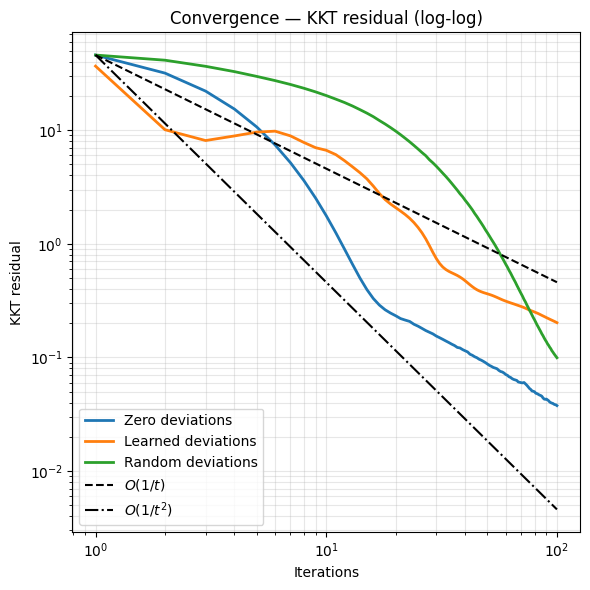

In [21]:
iters = np.arange(1, T_CMP + 1)
plt.figure(figsize=(6, 6) )
plt.loglog(iters, res_zero_cmp,    label='Zero deviations',    linewidth=2)
plt.loglog(iters, res_learned_cmp, label='Learned deviations', linewidth=2)
plt.loglog(iters,res_rand_cmp, label='Random deviations', linewidth=2)
plt.loglog(iters, res_zero_cmp[0] / iters,      'k--', label=r'$O(1/t)$')
plt.loglog(iters, res_zero_cmp[0] / iters**2,   'k-.', label=r'$O(1/t^2)$')
plt.xlabel('Iterations'); plt.ylabel('KKT residual')
plt.title('Convergence — KKT residual (log-log)')
plt.legend(); plt.grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.show()


### Distance to the optimal image (L2) — zero vs learned vs PDHG

The same `‖u_t − u*‖₂/‖u*‖₂` metric over the comparison horizon for the three solvers. Learned deviations should reach the optimal image **faster** than the zero-deviation baseline.

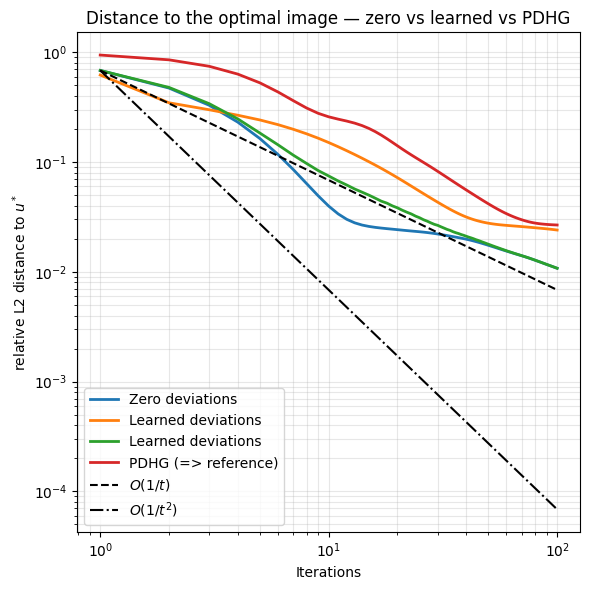

In [22]:
# Distance to the optimal image u* over the comparison horizon.
l2_zero_cmp    = l2_distance_history(x_hist[:T_CMP], u_ref)
l2_rand_cmp    = l2_distance_history(x_hist_rand[:T_CMP], u_ref)
l2_learned_cmp = l2_distance_history(hist_l['x'][:T_CMP], u_ref)

# PDHG: track its own L2-to-ref per iteration via the objective hook.
_uref_norm = u_ref.norm().clamp(min=1e-12).item()
def _l2_to_ref(u, w):
    return (u - u_ref).norm().item() / _uref_norm
_rec_pdhg_l2, l2_pdhg_cmp = run_pdhg(setup, params, niter=T_CMP,
                                     verbose=False, obj_fn=_l2_to_ref)
l2_pdhg_cmp = np.asarray(l2_pdhg_cmp)

iters = np.arange(1, T_CMP+1 )
plt.figure(figsize=(6, 6))
plt.loglog(iters, l2_zero_cmp,    label='Zero deviations',    lw=2)
plt.loglog(iters, l2_learned_cmp, label='Learned deviations', lw=2)
plt.loglog(iters, l2_rand_cmp, label='Learned deviations', lw=2)
plt.loglog(iters, l2_pdhg_cmp,    label='PDHG (=> reference)', lw=2)
plt.loglog(iters, l2_zero_cmp[0]/iters,    'k--', label=r'$O(1/t)$')
plt.loglog(iters, l2_zero_cmp[0]/iters**2, 'k-.', label=r'$O(1/t^2)$')
plt.xlabel('Iterations'); plt.ylabel(r'relative L2 distance to $u^*$')
plt.title('Distance to the optimal image — zero vs learned vs PDHG')
plt.legend(); plt.grid(True, which='both', alpha=0.3); plt.tight_layout(); plt.show()

### Global comparison with PDHG — PSNR vs iterations

Reconstruction quality against the phantom for the three solvers over the same `T_CMP` iterations.

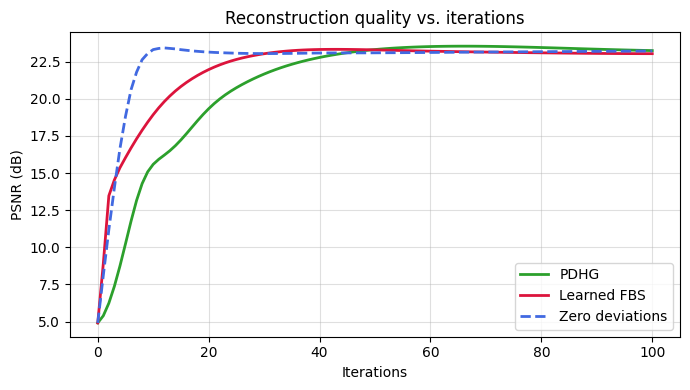

PSNR after 100 iterations:
  Zero deviations : 23.21 dB
  Learned FBS     : 23.03 dB  (-0.18 dB)
  PDHG            : 23.24 dB


In [23]:
u0 = torch.zeros_like(clean_t)               # l'état de départ commun
psnr_init = psnr_history([u0], clean_t)[0]

psnr_zero    = [psnr_init] + list(psnr_zero)
psnr_learned = [psnr_init] + list(psnr_learned)
psnr_pdhg    = [psnr_init] + list(psnr_pdhg)



plt.figure(figsize=(7, 4))
plt.plot(psnr_pdhg,    label='PDHG',            color='tab:green', linewidth=2)
plt.plot(psnr_learned, label='Learned FBS',     color='crimson',   linewidth=2)
plt.plot(psnr_zero,    label='Zero deviations', color='royalblue', linewidth=2, linestyle='--')
plt.xlabel('Iterations'); plt.ylabel('PSNR (dB)')
plt.title('Reconstruction quality vs. iterations')
plt.legend(); plt.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()

print(f'PSNR after {T_CMP} iterations:')
print(f'  Zero deviations : {psnr_zero[-1]:.2f} dB')
print(f'  Learned FBS     : {psnr_learned[-1]:.2f} dB  ({psnr_learned[-1]-psnr_zero[-1]:+.2f} dB)')
print(f'  PDHG            : {psnr_pdhg[-1]:.2f} dB')


### Visual comparison

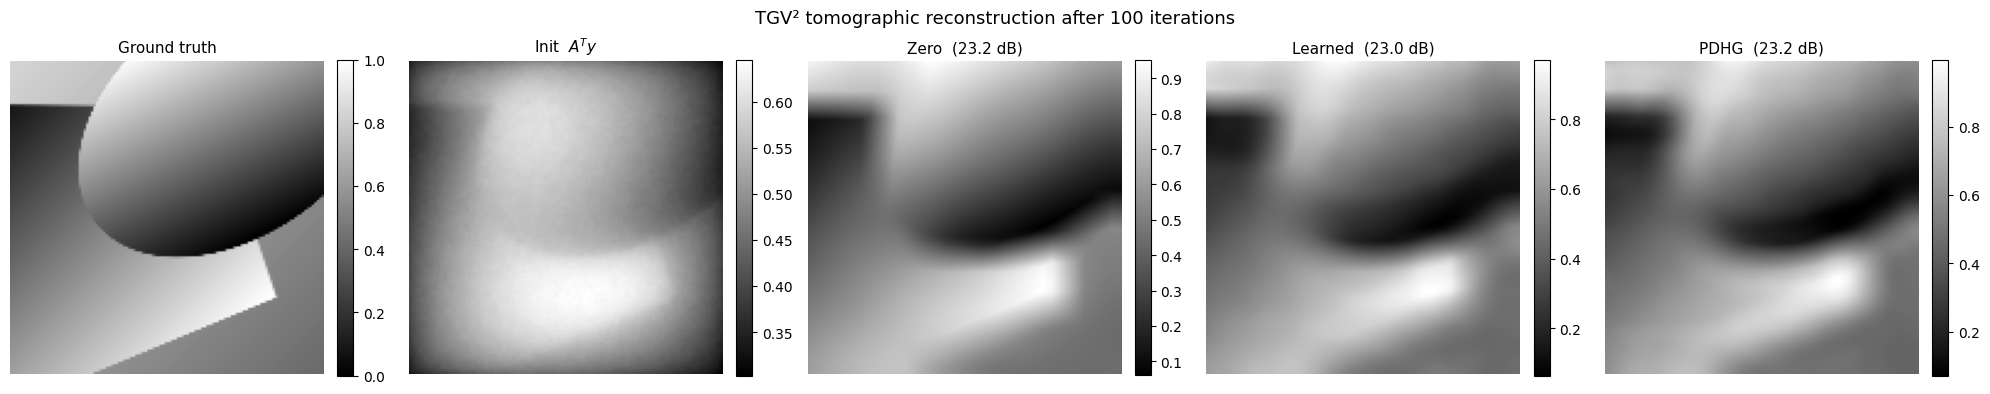

In [24]:
u_true    = clean_t[0, 0].cpu().numpy()
u_init    = init_t[0, 0].cpu().numpy()
u_zero    = x_hist[T_CMP-1][0][0, 0].cpu().numpy()
u_learned = hist_l['x'][-1][0][0, 0].cpu().numpy()
u_pdhg    = rec_pdhg_cmp[0, 0].cpu().numpy()

imgs   = [u_true, u_init, u_zero, u_learned, u_pdhg]
titles = ['Ground truth', r'Init  $A^T y$',
          f'Zero  ({psnr_zero[-1]:.1f} dB)',
          f'Learned  ({psnr_learned[-1]:.1f} dB)',
          f'PDHG  ({psnr_pdhg[-1]:.1f} dB)']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, img, title in zip(axes, imgs, titles):
    im = ax.imshow(img, cmap='gray'); ax.set_title(title, fontsize=11); ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.suptitle(f'TGV² tomographic reconstruction after {T_CMP} iterations', fontsize=13)
plt.tight_layout(); plt.show()


coc_max = 2/(lam0*beta_bar) = 2.222   (auto gamma = 0.500)
iter:0
60.10205078125
iter:1
54.747413635253906
iter:2
49.87726593017578
iter:3
45.44813537597656
iter:4
41.42046356201172
iter:5
37.75825119018555
iter:6
34.42875289916992
iter:7
31.40216064453125
iter:8
28.651363372802734
iter:9
26.151683807373047
iter:10
23.88066291809082
iter:11


21.81787872314453
iter:12
19.94472885131836
iter:13
18.24428939819336
iter:14
16.70115089416504
iter:15
15.301285743713379
iter:16
14.031914710998535
iter:17
12.881399154663086
iter:18
11.83912467956543
iter:19
10.895417213439941
iter:20
10.0414457321167
iter:21
9.269145965576172
iter:22
8.571146011352539
iter:23
7.940702438354492
iter:24
7.371638774871826
iter:25
6.858293056488037
iter:26
6.395469665527344
iter:27
5.978397846221924
iter:28
5.602694034576416
iter:29
5.264331340789795
iter:30
4.959608554840088
iter:31
4.685129642486572
iter:32
4.43778133392334
iter:33
4.2147135734558105
iter:34
4.013326644897461
iter:35
3.8312556743621826
iter:36
3.6663546562194824
iter:37
3.5166854858398438
iter:38
3.3805034160614014
iter:39
3.256246328353882
iter:40
3.1425187587738037
iter:41
3.0380802154541016
iter:42
2.941833019256592
iter:43
2.852809190750122
iter:44
2.770155906677246
iter:45
2.693127393722534
iter:46
2.6210708618164062
iter:47
2.553417205810547
iter:48
2.4896719455718994
iter:49
2

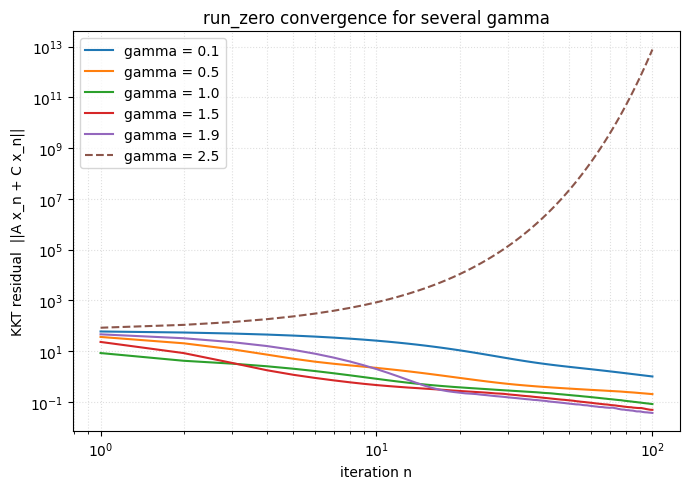

In [25]:
# ---- run_zero convergence for several gamma -------------------------------
import os
import numpy as np
import matplotlib.pyplot as plt

from run import run_zero

# coc_max = 2/(lam0*beta_bar) is the theoretical upper bound on gamma.
coc_max = 2.0 / (params.lam0 * params.beta_bar)
gamma_auto = params.gamma0                       # the value build_algo_functions picked
print(f"coc_max = 2/(lam0*beta_bar) = {coc_max:.3f}   (auto gamma = {gamma_auto:.3f})")

# a few values below the bound + one above it to show divergence
gammas  = [0.1, 0.5, 1.0, 1.5, 1.9, 2.5]
T_sweep = 100

curves = {}
for g in gammas:
    params.gamma0 = g          # RA/theta read params.gamma(n) dynamically -> no rebuild
    AxCx, _res, _hist = run_zero(init_t, functions, params, SHAPES, T_sweep, device)
    curves[g] = np.asarray(AxCx)

params.gamma0 = gamma_auto      # restore the automatic value

os.makedirs("plots", exist_ok=True)
plt.figure(figsize=(7, 5))
for g, c in curves.items():
    style = "--" if g > coc_max else "-"      # dashed = above the bound (diverges)
    plt.loglog(np.arange(1, len(c) + 1), c, style, label=f"gamma = {g}")
plt.xlabel("iteration n")
plt.ylabel("KKT residual  ||A x_n + C x_n||")
plt.title("run_zero convergence for several gamma")
plt.legend()
plt.grid(True, which="both", ls=":", alpha=0.4)
plt.tight_layout()
plt.savefig("plots/gamma_sweep.png", dpi=150)
plt.show()